In [3]:
import pandas as pd

df = pd.read_csv("powerplant_data.csv")
print(df.head())

      AT      V       AP     RH      PE
0   8.34  40.77  1010.84  90.01  480.48
1  23.64  58.49  1011.40  74.20  445.75
2  29.74  56.90  1007.15  41.91  438.76
3  19.07  49.69  1007.22  76.79  453.09
4  11.80  40.66  1017.13  97.20  464.43


In [4]:
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler_y = StandardScaler()

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)

In [14]:
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

#### Convert to PyTorch Tensors

In [7]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

#### Build ANN Model

In [8]:
import torch.nn as nn

class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ANN()

#### Loss & Optimizer

In [9]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Training Loop

In [10]:
epochs = 100

for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)
    loss = criterion(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 206946.6250
Epoch 10, Loss: 206856.5781
Epoch 20, Loss: 206768.0469
Epoch 30, Loss: 206678.8906
Epoch 40, Loss: 206585.6562
Epoch 50, Loss: 206482.7969
Epoch 60, Loss: 206365.7656
Epoch 70, Loss: 206231.3594
Epoch 80, Loss: 206075.7188
Epoch 90, Loss: 205894.3750


In [15]:
with torch.no_grad():
    y_pred = model(X_test).numpy()

# convert back to original scale
y_pred = scaler_y.inverse_transform(y_pred)
y_test_actual = scaler_y.inverse_transform(y_test.numpy())

#### Evaluation

In [11]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model.eval()

with torch.no_grad():
    y_pred = model(X_test).numpy()

y_test_np = y_test.numpy()

rmse = np.sqrt(mean_squared_error(y_test_np, y_pred))
r2 = r2_score(y_test_np, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 453.3177004044735
R2 Score: -717.1588745117188


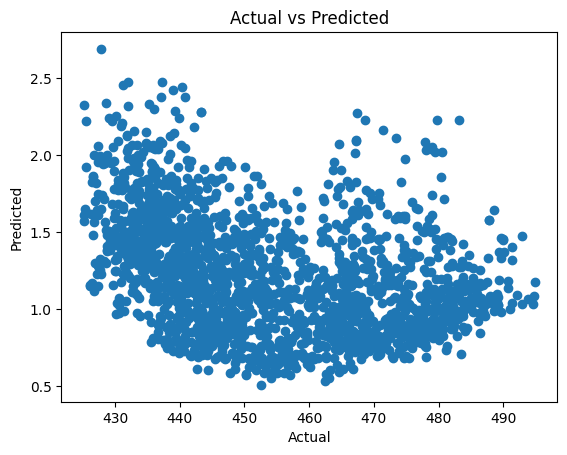

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test_np, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [16]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
r2 = r2_score(y_test_actual, y_pred)

In [17]:
rmse

29.144368685463384

In [18]:
r2

-1.9684138298034668